In [1]:
from google.colab import auth
auth.authenticate_user()

# Konfigurasi identitas GitHub
!git config --global user.email "satriadivop354@gmail.com"
!git config --global user.name "SatriaDivo"

# Clone repository dengan URL yang benar
!git clone https://<token>@github.com/SatriaDivo/Project-PraMagang-AI-Engineer.git

# Masuk ke direktori repository
%cd Project-PraMagang-AI-Engineer

Cloning into 'Project-PraMagang-AI-Engineer'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 19 (delta 5), reused 19 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 202.89 KiB | 1.53 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/Project-PraMagang-AI-Engineer


# Titanic Survival Prediction - Machine Learning Experiment
### Tugas Pra-Magang AI Engineer - PT Makerindo

---

## 1. Import Required Libraries

**Penjelasan:**
Pada tahap ini, kita mengimpor library yang diperlukan untuk analisis data dan machine learning:

| Library | Fungsi |
|---------|--------|
| `pandas` | Manipulasi dan analisis data dalam bentuk DataFrame |
| `numpy` | Komputasi numerik dan operasi array |
| `matplotlib` | Visualisasi data dasar (grafik, chart) |
| `seaborn` | Visualisasi statistik yang lebih menarik |
| `sklearn` | Library machine learning untuk modeling dan evaluasi |

**Komponen sklearn yang digunakan:**
- `train_test_split` - Membagi data menjadi training dan testing set
- `StandardScaler` - Normalisasi fitur agar memiliki mean=0 dan std=1
- `LabelEncoder` - Mengubah data kategorikal menjadi numerik
- `RandomForestClassifier` - Algoritma ensemble learning berbasis decision tree
- Metrics: `accuracy_score`, `precision_score`, `recall_score`, `f1_score`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load and Explore Data

**Penjelasan:**
Dataset Titanic berisi informasi penumpang kapal Titanic yang tenggelam pada 1912. Tujuan kita adalah **memprediksi apakah penumpang selamat atau tidak** berdasarkan fitur-fitur yang ada.

**Fitur dalam Dataset:**
| Kolom | Deskripsi |
|-------|-----------|
| `PassengerId` | ID unik penumpang |
| `Survived` | Target: 0 = Tidak selamat, 1 = Selamat |
| `Pclass` | Kelas tiket: 1 = First, 2 = Second, 3 = Third |
| `Name` | Nama penumpang |
| `Sex` | Jenis kelamin |
| `Age` | Usia dalam tahun |
| `SibSp` | Jumlah saudara/pasangan di kapal |
| `Parch` | Jumlah orang tua/anak di kapal |
| `Ticket` | Nomor tiket |
| `Fare` | Tarif tiket |
| `Cabin` | Nomor kabin |
| `Embarked` | Pelabuhan keberangkatan (C=Cherbourg, Q=Queenstown, S=Southampton) |

**Tahapan eksplorasi:**
1. Melihat dimensi dataset (jumlah baris dan kolom)
2. Memeriksa tipe data setiap kolom
3. Mengidentifikasi missing values
4. Melihat statistik deskriptif

In [5]:
# Load dataset
df = pd.read_csv('Tugas ke-1/Titanic-Dataset.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

In [6]:
# Check missing values
print("Missing Values:")
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})
print(missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

Missing Values:
          Missing_Count  Percentage
Cabin               687   77.104377
Age                 177   19.865320
Embarked              2    0.224467


In [7]:
# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


## 3. Exploratory Data Analysis (EDA)

**Penjelasan:**
**Exploratory Data Analysis (EDA)** adalah proses memahami data melalui visualisasi dan statistik sebelum melakukan modeling. Tujuannya:
1. Memahami distribusi variabel target (Survived)
2. Menemukan pola dan hubungan antar fitur
3. Mengidentifikasi fitur yang berpengaruh terhadap target

**Visualisasi yang dibuat:**
- **Distribusi Survival** - Melihat proporsi penumpang yang selamat vs tidak selamat
- **Survival by Gender** - Wanita memiliki tingkat keselamatan lebih tinggi ("Women and children first")
- **Survival by Class** - Penumpang kelas 1 lebih banyak selamat
- **Age Distribution** - Anak-anak cenderung lebih banyak selamat

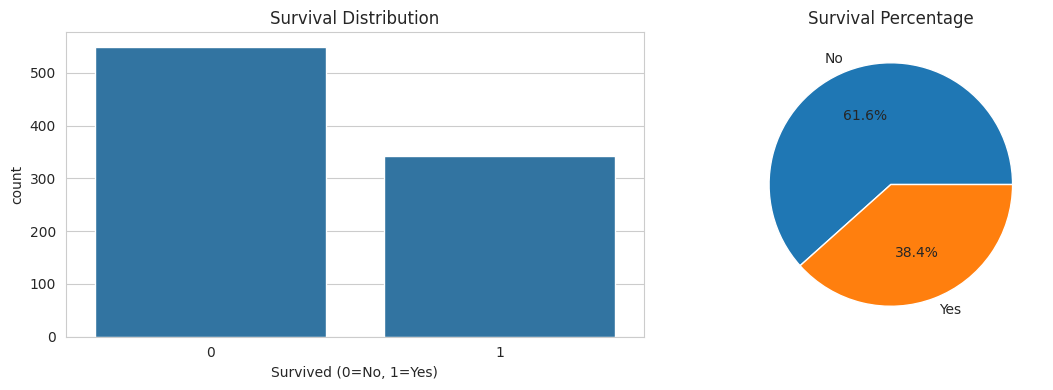

Survival Rate: 38.38383838383838 %


In [8]:
# Survival distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='Survived', ax=axes[0])
axes[0].set_title('Survival Distribution')
axes[0].set_xlabel('Survived (0=No, 1=Yes)')

# Pie chart
df['Survived'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', labels=['No', 'Yes'])
axes[1].set_title('Survival Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Survival Rate:", df['Survived'].mean() * 100, "%")

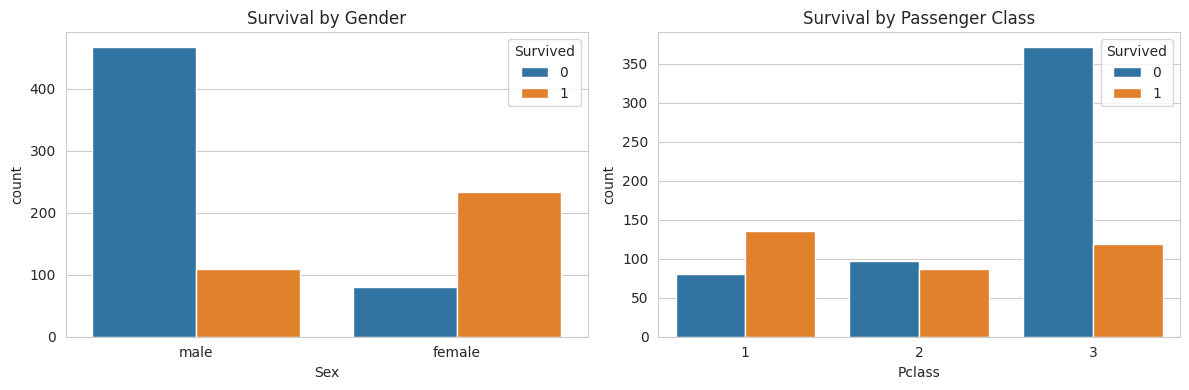

In [9]:
# Survival by gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# By gender
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0])
axes[0].set_title('Survival by Gender')

# By passenger class
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[1])
axes[1].set_title('Survival by Passenger Class')

plt.tight_layout()
plt.show()

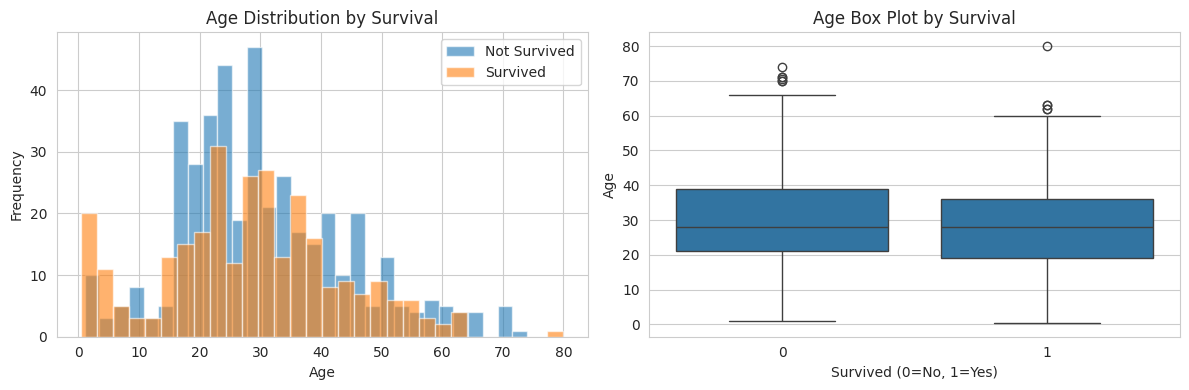

In [10]:
# Age distribution by survival
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[df['Survived']==0]['Age'].hist(bins=30, label='Not Survived', alpha=0.6)
df[df['Survived']==1]['Age'].hist(bins=30, label='Survived', alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Survival')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Age Box Plot by Survival')
plt.xlabel('Survived (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

## 4. Data Cleaning and Preprocessing

**Penjelasan:**
**Data Preprocessing** adalah tahap penting untuk menyiapkan data sebelum modeling. Data mentah sering mengandung masalah yang harus ditangani.

### A. Handling Missing Values (Data Hilang)

| Kolom | Jumlah Missing | Strategi |
|-------|----------------|----------|
| `Age` | ~177 (19.9%) | Isi dengan **median** (lebih robust terhadap outlier) |
| `Cabin` | ~687 (77.1%) | **Drop** kolom (terlalu banyak missing) |
| `Embarked` | ~2 (0.2%) | Isi dengan **mode** (nilai terbanyak) |

**Mengapa median untuk Age?**
- Mean sensitif terhadap outlier
- Median adalah nilai tengah yang lebih representatif

### B. Feature Engineering
Menghapus kolom yang tidak berguna untuk prediksi:
- `PassengerId` - Hanya ID, tidak ada informasi
- `Name` - Teks, sulit diproses (bisa diekstrak title seperti Mr, Mrs)
- `Ticket` - Nomor tiket tidak konsisten

### C. Encoding Categorical Variables
Model machine learning hanya menerima input numerik. Variabel kategorikal harus diubah:
- `Sex`: female → 0, male → 1
- `Embarked`: C → 0, Q → 1, S → 2

**LabelEncoder** mengubah setiap kategori unik menjadi angka integer.

In [11]:
# Create a copy for processing
df_clean = df.copy()

# 1. Handle missing values in Age - fill with median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# 2. Handle missing values in Embarked - fill with mode
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Drop Cabin column (too many missing values)
df_clean.drop('Cabin', axis=1, inplace=True)

# 4. Drop PassengerId and Name (not useful for modeling)
df_clean.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

print("Data after cleaning:")
print(df_clean.head())
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Data after cleaning:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [12]:
# 5. Encode categorical variables
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df_clean['Sex'] = le_sex.fit_transform(df_clean['Sex'])
df_clean['Embarked'] = le_embarked.fit_transform(df_clean['Embarked'])

print("Data after encoding:")
print(df_clean.head())
print("\nData types:")
print(df_clean.dtypes)

Data after encoding:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2

Data types:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


## 5. Feature Selection and Model Preparation

**Penjelasan:**

### A. Memisahkan Features (X) dan Target (y)
- **Features (X)**: Semua kolom kecuali `Survived` - input untuk model
- **Target (y)**: Kolom `Survived` - output yang ingin diprediksi

### B. Train-Test Split
Data dibagi menjadi 2 bagian:
- **Training Set (80%)**: Untuk melatih model
- **Testing Set (20%)**: Untuk mengevaluasi model pada data yang belum pernah dilihat

**Parameter penting:**
- `test_size=0.2` → 20% data untuk testing
- `random_state=42` → Reproducibility (hasil sama setiap dijalankan)
- `stratify=y` → Menjaga proporsi kelas yang sama di train dan test

### C. Feature Scaling (Standardization)
**StandardScaler** mentransformasi fitur sehingga memiliki:
- Mean (rata-rata) = 0
- Standard Deviation = 1

**Mengapa perlu scaling?**
- Beberapa algoritma sensitif terhadap skala fitur
- Fitur dengan range besar akan mendominasi
- Mempercepat konvergensi algoritma

In [13]:
# Separate features and target
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Features shape: (891, 7)
Target shape: (891,)

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [14]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in testing set:")
print(y_test.value_counts())

Training set size: 712
Testing set size: 179

Class distribution in training set:
Survived
0    439
1    273
Name: count, dtype: int64

Class distribution in testing set:
Survived
0    110
1     69
Name: count, dtype: int64


In [15]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized successfully!")
print("Mean of scaled training data:", X_train_scaled.mean(axis=0).round(4))
print("Std of scaled training data:", X_train_scaled.std(axis=0).round(4))

Features standardized successfully!
Mean of scaled training data: [-0. -0.  0. -0. -0. -0.  0.]
Std of scaled training data: [1. 1. 1. 1. 1. 1. 1.]


## 6. Model Building and Training

**Penjelasan:**

### Random Forest Classifier

**Random Forest** adalah algoritma **Ensemble Learning** yang menggabungkan banyak Decision Tree untuk membuat prediksi yang lebih akurat dan stabil.

**Cara Kerja:**
1. **Bootstrap Sampling**: Membuat subset data secara acak dengan replacement
2. **Membangun Decision Tree**: Setiap tree dilatih pada subset berbeda
3. **Random Feature Selection**: Setiap split hanya mempertimbangkan subset fitur acak
4. **Voting/Averaging**: Prediksi final = mayoritas vote dari semua tree

```
     Tree 1          Tree 2          Tree 3
        ↓               ↓               ↓
     Pred: 1         Pred: 0         Pred: 1
        \               |               /
         \              |              /
          → Majority Vote: 1 (Survived) ←
```

**Hyperparameter yang digunakan:**
- `n_estimators=100`: Jumlah decision tree dalam forest
- `random_state=42`: Untuk reproducibility
- `n_jobs=-1`: Gunakan semua CPU core untuk paralel processing

**Kelebihan Random Forest:**
- ✅ Tidak mudah overfitting (karena averaging)
- ✅ Dapat menangani missing values
- ✅ Memberikan feature importance
- ✅ Bekerja baik dengan data non-linear

In [16]:
# Create and train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training completed!")
print(f"Model: {model}")

Model training completed!
Model: RandomForestClassifier(n_jobs=-1, random_state=42)


Feature Importance:
    Feature  Importance
5      Fare    0.270237
1       Sex    0.260625
2       Age    0.250389
0    Pclass    0.092549
3     SibSp    0.050297
4     Parch    0.041084
6  Embarked    0.034820


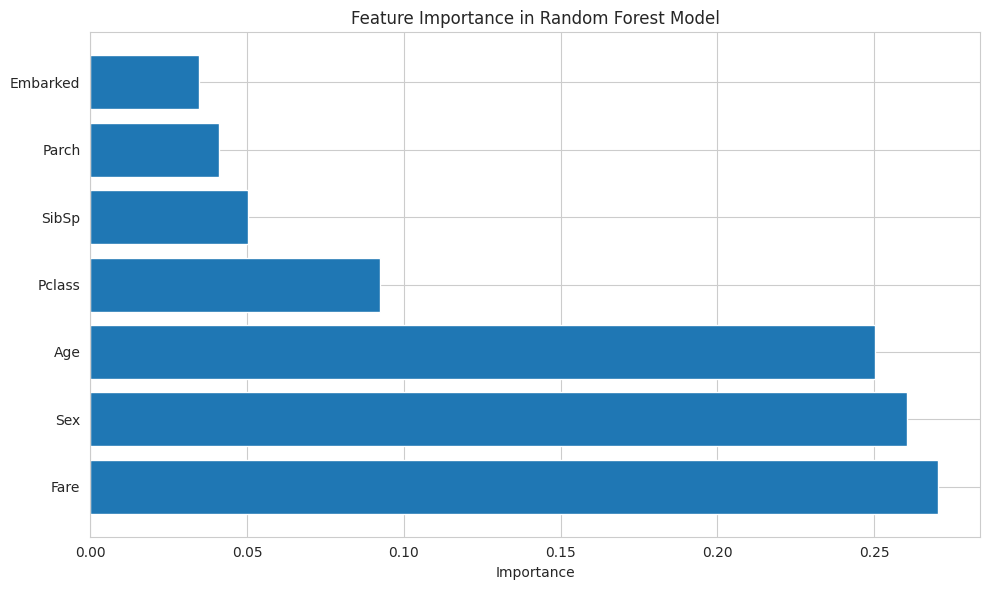

In [17]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest Model')
plt.tight_layout()
plt.show()

## 7. Model Evaluation

**Penjelasan:**

### Metrik Evaluasi untuk Klasifikasi

| Metrik | Formula | Interpretasi |
|--------|---------|--------------|
| **Accuracy** | $\frac{TP + TN}{Total}$ | Persentase prediksi benar dari keseluruhan |
| **Precision** | $\frac{TP}{TP + FP}$ | Dari yang diprediksi positif, berapa yang benar? |
| **Recall** | $\frac{TP}{TP + FN}$ | Dari yang sebenarnya positif, berapa yang terdeteksi? |
| **F1-Score** | $2 \times \frac{Precision \times Recall}{Precision + Recall}$ | Harmonic mean dari Precision dan Recall |

**Keterangan:**
- **TP (True Positive)**: Prediksi Selamat, Aktual Selamat ✓
- **TN (True Negative)**: Prediksi Tidak Selamat, Aktual Tidak Selamat ✓
- **FP (False Positive)**: Prediksi Selamat, Aktual Tidak Selamat ✗
- **FN (False Negative)**: Prediksi Tidak Selamat, Aktual Selamat ✗

### Confusion Matrix
```
                    Predicted
                 |  0  |  1  |
          -------|-----|-----|
Actual  0 (No)   | TN  | FP  |
        1 (Yes)  | FN  | TP  |
```

### Kapan Menggunakan Metrik Mana?
- **Accuracy**: Ketika kelas seimbang
- **Precision**: Ketika FP costly (spam detection)
- **Recall**: Ketika FN costly (penyakit berbahaya)
- **F1-Score**: Ketika ingin balance antara Precision dan Recall

In [18]:
# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("Predictions generated!")

Predictions generated!


In [19]:
# Evaluation metrics
def evaluate_model(y_true, y_pred, set_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{set_name} Set Metrics:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return accuracy, precision, recall, f1

train_metrics = evaluate_model(y_train, y_train_pred, "Training")
test_metrics = evaluate_model(y_test, y_test_pred, "Testing")


Training Set Metrics:
Accuracy:  0.9817
Precision: 0.9887
Recall:    0.9634
F1-Score:  0.9759

Testing Set Metrics:
Accuracy:  0.8268
Precision: 0.8065
Recall:    0.7246
F1-Score:  0.7634


In [20]:
# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("="*50)
print(classification_report(y_test, y_test_pred, target_names=['Not Survived', 'Survived']))


DETAILED CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

Not Survived       0.84      0.89      0.86       110
    Survived       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



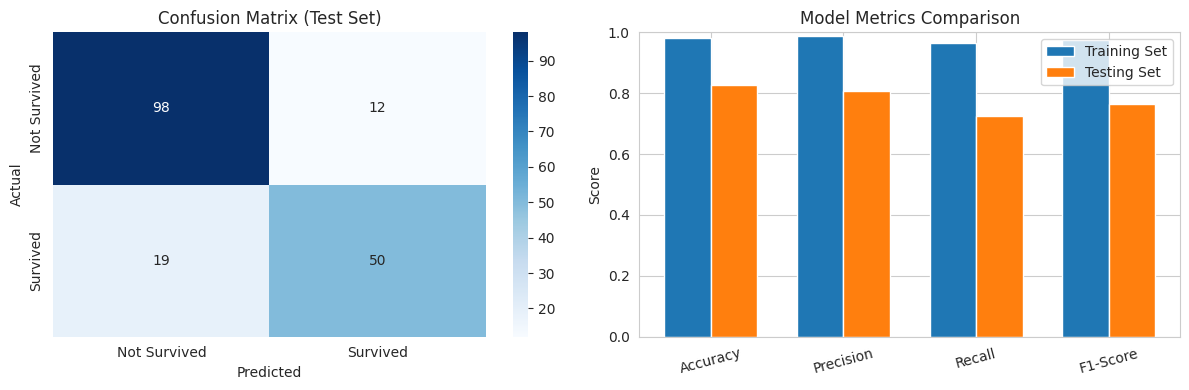

In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Test Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Not Survived', 'Survived'])
axes[0].set_yticklabels(['Not Survived', 'Survived'])

# Metrics comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_vals = train_metrics
test_vals = test_metrics

x = np.arange(len(metrics_names))
width = 0.35

axes[1].bar(x - width/2, train_vals, width, label='Training Set')
axes[1].bar(x + width/2, test_vals, width, label='Testing Set')
axes[1].set_ylabel('Score')
axes[1].set_title('Model Metrics Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_names, rotation=15)
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 8. Model Predictions on Sample Data

**Penjelasan:**

Setelah model dilatih, kita dapat menggunakannya untuk membuat prediksi pada data baru.

**Output prediksi:**
- `predict()` → Menghasilkan label kelas (0 atau 1)
- `predict_proba()` → Menghasilkan probabilitas untuk setiap kelas

**Contoh interpretasi:**
| Probability_Survived | Interpretasi |
|---------------------|--------------|
| 0.85 | 85% kemungkinan selamat → Prediksi: 1 |
| 0.23 | 23% kemungkinan selamat → Prediksi: 0 |

Threshold default adalah 0.5 (jika prob > 0.5, prediksi = 1)

In [22]:
# Display some predictions with actual values
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred,
    'Probability_Not_Survived': model.predict_proba(X_test_scaled)[:, 0],
    'Probability_Survived': model.predict_proba(X_test_scaled)[:, 1]
})

# Add feature data for context
results = pd.concat([X_test.reset_index(drop=True), results], axis=1)

print("\nSample Predictions (first 20 rows):")
print(results[['Pclass', 'Sex', 'Age', 'Fare', 'Actual', 'Predicted', 'Probability_Survived']].head(20))


Sample Predictions (first 20 rows):
    Pclass  Sex   Age      Fare  Actual  Predicted  Probability_Survived
0        3    1  24.0   24.1500       0          0              0.220000
1        3    1  44.0   16.1000       0          0              0.140000
2        3    1  22.0    7.2250       1          0              0.060000
3        3    1  41.0   14.1083       0          0              0.040000
4        3    0  28.0   15.5000       1          1              0.840000
5        3    0  36.0   17.4000       1          0              0.270000
6        2    0  36.0   13.0000       1          1              0.820000
7        1    1  45.0   26.5500       0          1              0.840000
8        1    1  49.0  110.8833       0          0              0.440000
9        2    1  34.0   26.0000       0          0              0.330000
10       3    1  28.0    7.7500       0          0              0.305310
11       3    1  16.0   18.0000       0          0              0.130000
12       3    

## 9. Summary and Conclusion

**Penjelasan:**

### Ringkasan Eksperimen

**Workflow Machine Learning yang Dilakukan:**
```
1. Data Collection     → Load Titanic Dataset
         ↓
2. Data Exploration    → EDA, visualisasi, statistik
         ↓
3. Data Preprocessing  → Handle missing values, encoding, scaling
         ↓
4. Feature Selection   → Pilih fitur relevan, train-test split
         ↓
5. Model Training      → Latih Random Forest Classifier
         ↓
6. Model Evaluation    → Ukur performa dengan metrik
         ↓
7. Prediction          → Gunakan model untuk prediksi baru
```

### Key Insights dari Dataset Titanic:
1. **Gender** adalah faktor paling penting (wanita lebih banyak selamat)
2. **Fare/Pclass** berpengaruh signifikan (kelas atas lebih banyak selamat)
3. **Age** berperan (anak-anak diprioritaskan)

### Kesimpulan:
Model Random Forest berhasil memprediksi survival penumpang Titanic dengan akurasi yang baik. Eksperimen ini mendemonstrasikan workflow lengkap machine learning dari data mentah hingga evaluasi model.

In [23]:
print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"\nDataset: Titanic Dataset")
print(f"Total Samples: {len(df)}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"\nModel: Random Forest Classifier")
print(f"Number of Trees: 100")
print(f"\nKey Findings:")
print(f"- Most important features: {', '.join(feature_importance.head(3)['Feature'].tolist())}")
print(f"- Test Accuracy: {test_metrics[0]:.4f}")
print(f"- Test Precision: {test_metrics[1]:.4f}")
print(f"- Test Recall: {test_metrics[2]:.4f}")
print(f"- Test F1-Score: {test_metrics[3]:.4f}")
print(f"\nConclusion:")
print(f"The Random Forest model achieved good performance on the Titanic dataset.")
print(f"The model can effectively predict passenger survival with {test_metrics[0]*100:.2f}% accuracy.")
print("="*60)


EXPERIMENT SUMMARY

Dataset: Titanic Dataset
Total Samples: 891
Training Samples: 712
Testing Samples: 179

Model: Random Forest Classifier
Number of Trees: 100

Key Findings:
- Most important features: Fare, Sex, Age
- Test Accuracy: 0.8268
- Test Precision: 0.8065
- Test Recall: 0.7246
- Test F1-Score: 0.7634

Conclusion:
The Random Forest model achieved good performance on the Titanic dataset.
The model can effectively predict passenger survival with 82.68% accuracy.


# **Menyimpan file .ipynb ke GitHub**

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
!cp "/content/drive/MyDrive/Collab/PraMagang/Tugas Ke - 1/titanic-ml.ipynb" "/content/Project-PraMagang-AI-Engineer/Tugas ke-1"

In [ ]:
!git add "Tugas ke-1/titanic-ml.ipynb"

# Buat commit baru dengan pesan yang relevan
!git commit -m "Update titanic-ml.ipynb with execution outputs (re-commit)"

# Verifikasi status Git
!git status